<a href="https://colab.research.google.com/github/EgorKaduba/ForecastRus/blob/ml-predict/ml/predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Предразминка


In [489]:
!pip install catboost -q
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from tqdm import tqdm
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error, mean_absolute_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

In [490]:
df = pd.read_csv('/content/Full_df.csv')
df = df.sort_values(['oktmo', 'year'])

In [491]:
df2 = df.dropna()

In [492]:
df2.rename({'deaths':'death'}, axis=1, inplace = True)
df.rename({'deaths':'death'}, axis=1, inplace = True)

In [493]:
na_cols = ['death', 'births', 'migration']
feature_cols = ['Target', 'year']
for j in na_cols:
  for i in range(1, 8):
    df2[f'{j}{i}'] = df2.groupby(
        ['region_name', 'municipality', 'oktmo', 'mun_type']
    )[f'{j}'].shift(i)
    feature_cols.append(f'{j}{i}')

  cat_features = categorical_features =  ['region_name', 'municipality', 'oktmo', 'mun_type']

  for i in cat_features:
    df2[i] = df2[i].astype('category')

  X = df2[feature_cols + cat_features]
  y = df2[f'{j}']


  model = LGBMRegressor(
      n_estimators=500,
      learning_rate=0.05,
      max_depth=7,
      random_state=42,
      verbose=-1,
      categorical_feature=cat_features
      )
  model.fit(X, y)


  res = df[df[f'{j}'].isna()]
  ind_death = df[df[f'{j}'].isna()].index
  for i in range(1, 8):
      df[f'{j}{i}'] = df.groupby(
          ['region_name', 'municipality', 'oktmo', 'mun_type']
      )[f'{j}'].shift(i)



  for i in cat_features:
    df[i] = df[i].astype('category')
  res = df[df[f'{j}'].isna()].drop(f'{j}', axis = 1)
  ind_death = df[df[f'{j}'].isna()].index
  res= res[feature_cols+cat_features]
  predict = model.predict(res)
  df[f'{j}'].iloc[ind_death] = predict

In [494]:
df.rename({'death': 'deaths'}, axis = 1, inplace=True)

In [495]:
df = df[['region_name','municipality', 'oktmo', 'mun_type', 'year', 'Target', 'deaths', 'births','migration']]

In [496]:
df.isna().sum()

,0
region_name,0
municipality,0
oktmo,0
mun_type,0
year,0
Target,2
deaths,0
births,0
migration,0


#Метрики


In [476]:
train_df = df[df['year'] < 2020].copy()
test_df = df[(df['year'] >= 2020) & (df['oktmo']!=42630000)].copy()


LAGS = [1, 2, 3]
features = []

for col in ['births', 'deaths', 'migration']:
    for lag in LAGS:
        train_df[f'{col}_lag{lag}'] = train_df.groupby('oktmo')[col].shift(lag)
        features.append(f'{col}_lag{lag}')

train_df['year_norm'] = train_df['year'] - train_df['year'].min()
features.append('year_norm')

cat_features = ['region'] if 'region' in train_df.columns else []

train_model = train_df.dropna().copy()


targets = ['births', 'deaths', 'migration']
models = {}

for target in targets:
    model = CatBoostRegressor(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    )
    model.fit(
        train_model[features + cat_features],
        train_model[target],
        cat_features=cat_features
    )
    models[target] = model


def forecast(train_history, models, horizon=5):

    df_future = train_history.copy()
    last_year = df_future['year'].max()

    for step in tqdm(range(1, horizon + 1)):
        year = last_year + step


        df_step = df_future.groupby('oktmo').tail(1).copy()
        df_step['year'] = year
        df_step['year_norm'] = year - train_history['year'].min()

        for col in ['births', 'deaths', 'migration']:
            hist = df_future.groupby('oktmo')[col]
            df_step[f'{col}_lag1'] = hist.tail(1).values
            df_step[f'{col}_lag2'] = hist.tail(2).groupby(df_future['oktmo']).head(1).values
            df_step[f'{col}_lag3'] = hist.tail(3).groupby(df_future['oktmo']).head(1).values


        for target in targets:
            pred = models[target].predict(df_step[features + cat_features])
            prev = df_step[f'{target}_lag1']
            pred = np.clip(pred, prev * 0.97, prev * 1.03)
            df_step[target] = pred


        prev_pop = df_step['Target']
        df_step['Target'] = prev_pop + df_step['births'] - df_step['deaths'] + df_step['migration']
        df_step['Target'] = np.clip(df_step['Target'], prev_pop * 0.97, prev_pop * 1.03)

        df_future = pd.concat([df_future, df_step], ignore_index=True)


    return df_future[df_future['year'] > last_year]

forecast_df = forecast(train_model, models, horizon=5)


comparison = forecast_df[['oktmo', 'year', 'Target']].merge(
    test_df[['oktmo', 'year', 'Target']],
    on=['oktmo', 'year'],
    suffixes=('_pred', '_true')
)

comparison['ape'] = 100 * np.abs(comparison['Target_pred'] - comparison['Target_true']) / np.abs(comparison['Target_true'])


mape_total = comparison['ape'].mean()
print(f'\nMAPE {mape_total:.2f}%')
print(f'MAE {mean_absolute_error(comparison['Target_true'], comparison['Target_pred'])}')
print(f'RMSE {mean_squared_error(comparison['Target_true'], comparison['Target_pred'])**0.5}')



100%|██████████| 5/5 [00:00<00:00, 21.41it/s]


MAPE 2.95%
MAE 1583.2655340537601
RMSE 7156.884197808266


#Предикт


In [497]:
LAGS = [1, 2, 3]
features = []

for col in ['births', 'deaths', 'migration']:
    for lag in LAGS:
        df[f'{col}_lag{lag}'] = df.groupby('oktmo')[col].shift(lag)
        features.append(f'{col}_lag{lag}')

df['year_norm'] = df['year'] - df['year'].min()
features.append('year_norm')

cat_features = ['region'] if 'region' in df.columns else []


df_model = df.dropna().copy()


models = {}
targets = ['births', 'deaths', 'migration']

for target in targets:
    print(f'Training {target}')
    model = CatBoostRegressor(
        iterations=600,
        depth=8,
        learning_rate=0.01,
        verbose=False
    )

    model.fit(
        df_model[features + cat_features],
        df_model[target],
        cat_features=cat_features
    )

    models[target] = model


def forecast(df, models, horizon=15):
    df_future = df.copy()
    step = 1

    for _ in tqdm(range(1, horizon + 1)):

        df_step = df_future.groupby('oktmo').tail(1).copy()
        year = df_step['year'] + step
        df_step['year'] = year
        df_step['year_norm'] = year - df_future['year'].min()


        for col in ['births', 'deaths', 'migration']:
            hist = df_future.groupby('oktmo')[col]

            df_step[f'{col}_lag1'] = hist.tail(1).values
            df_step[f'{col}_lag2'] = hist.tail(2).groupby(df_future['oktmo']).head(1).values
            df_step[f'{col}_lag3'] = hist.tail(3).groupby(df_future['oktmo']).head(1).values


        for target in ['births', 'deaths', 'migration']:
            pred = models[target].predict(df_step[features + cat_features])
            prev = df_step[f'{target}_lag1']


            pred = np.clip(pred, prev * 0.97, prev * 1.03)
            df_step[target] = pred


        prev_pop = df_step['Target']

        df_step['Target'] = (
            prev_pop
            + df_step['births']
            - df_step['deaths']
            + df_step['migration']
        )

        df_step['Target'] = np.clip(df_step['Target'], prev_pop * 0.97, prev_pop * 1.03)

        df_future = pd.concat([df_future, df_step], ignore_index=True)

    return df_future

forecast_df = forecast(df_model, models, horizon=15)
forecast_df[['year','Target','deaths','births','migration']] = forecast_df[['year','Target','deaths','births','migration']].astype('int64')
forecast_df = forecast_df[forecast_df['year']<=2035]
forecast_df[['region_name',	'municipality',	'oktmo',	'mun_type',	'year',	'Target',	'deaths',	'births',	'migration']].to_csv('forecast_2035.csv', index=False)

Training births
Training deaths
Training migration


100%|██████████| 15/15 [00:00<00:00, 25.72it/s]


#Графики

In [498]:
import seaborn as sns
import matplotlib.pyplot as plt

In [506]:
pred_cols = ['Target',	'deaths', 'births', 'migration']

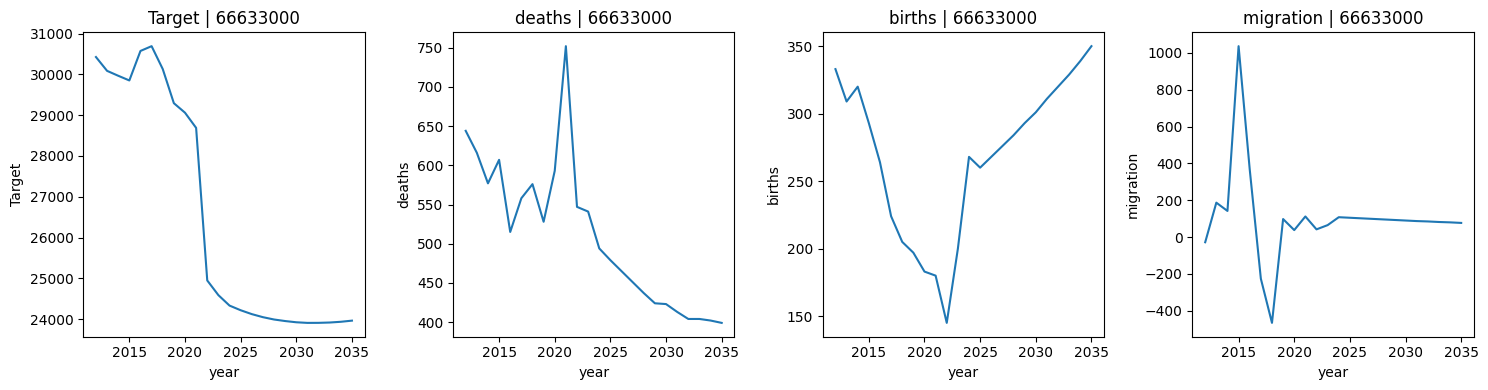

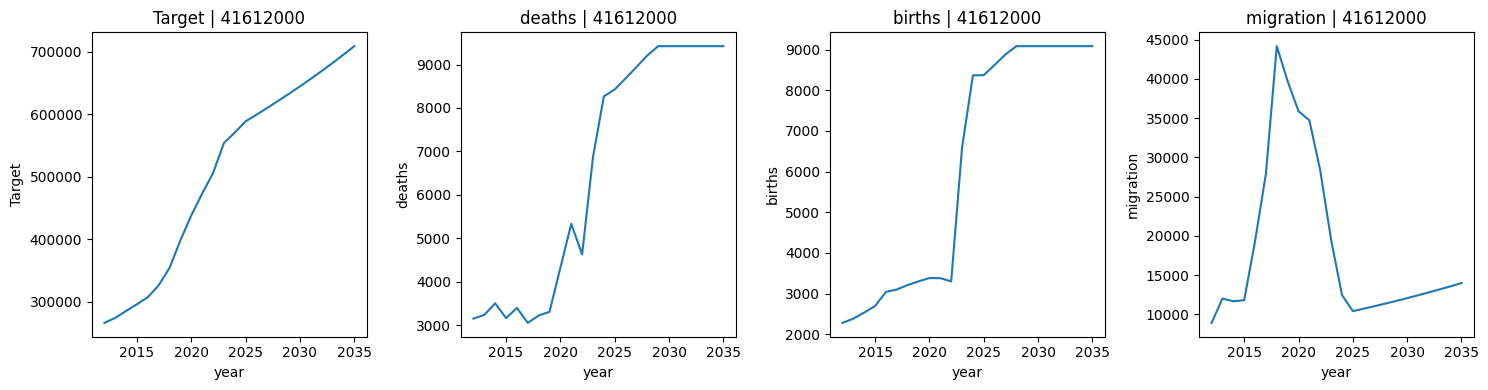

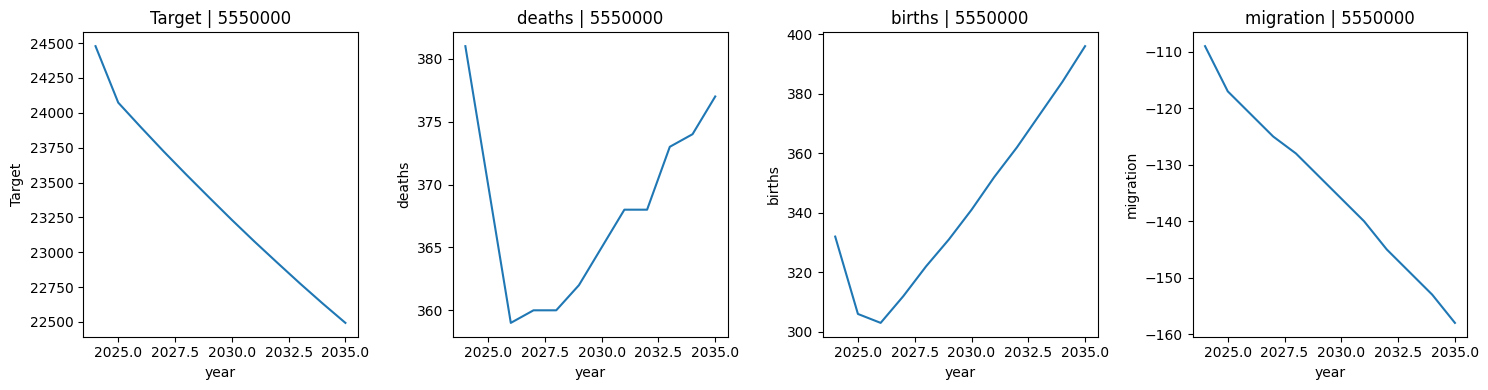

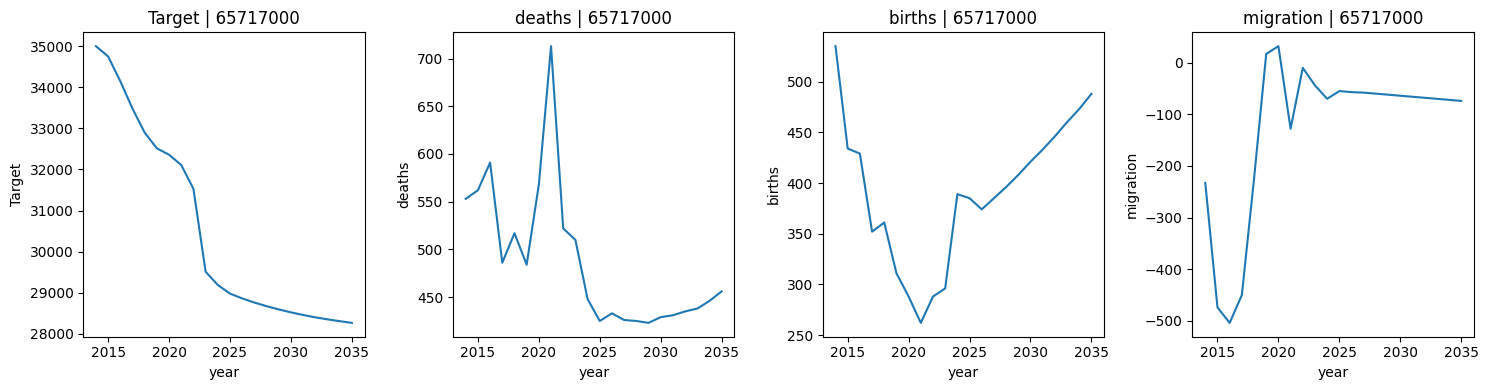

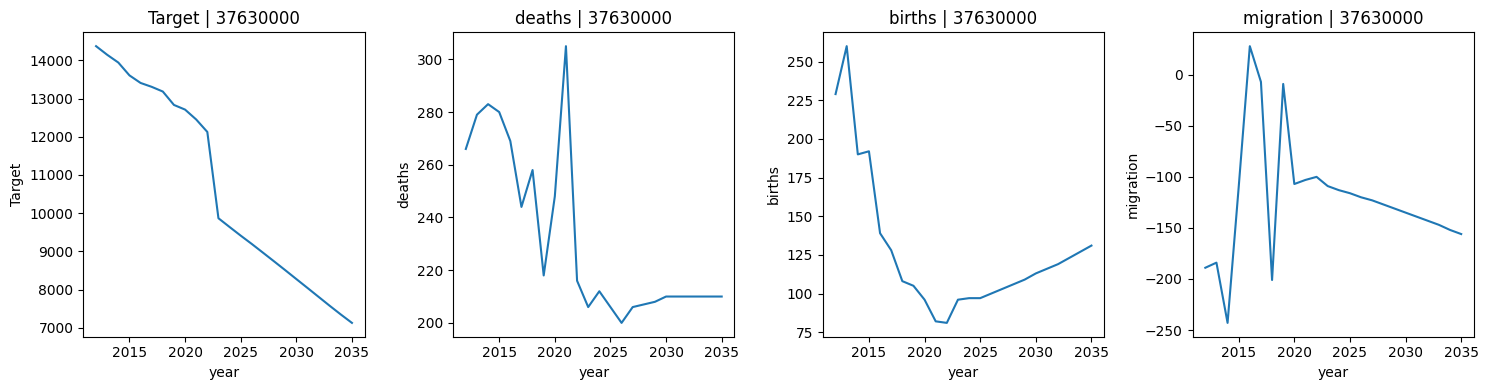

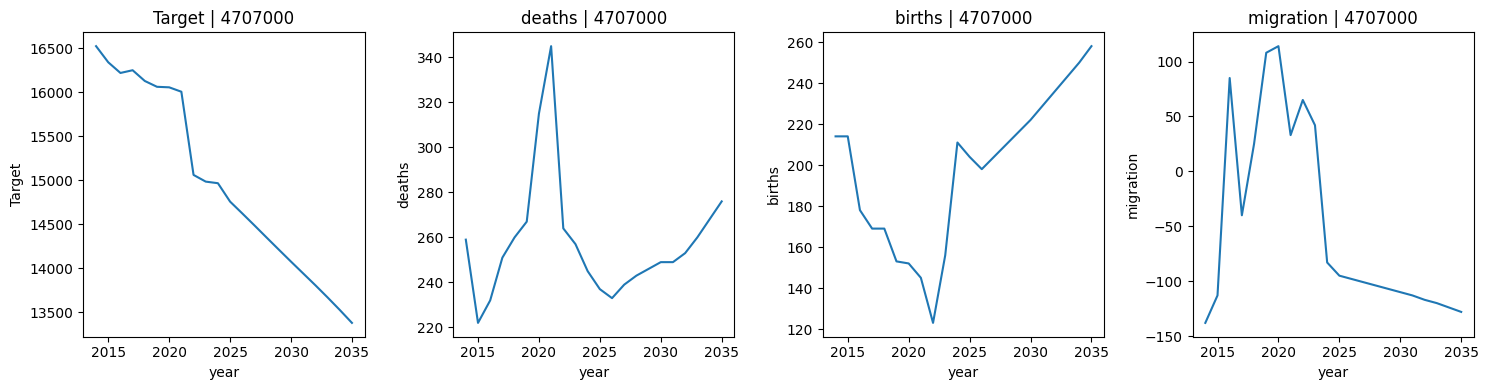

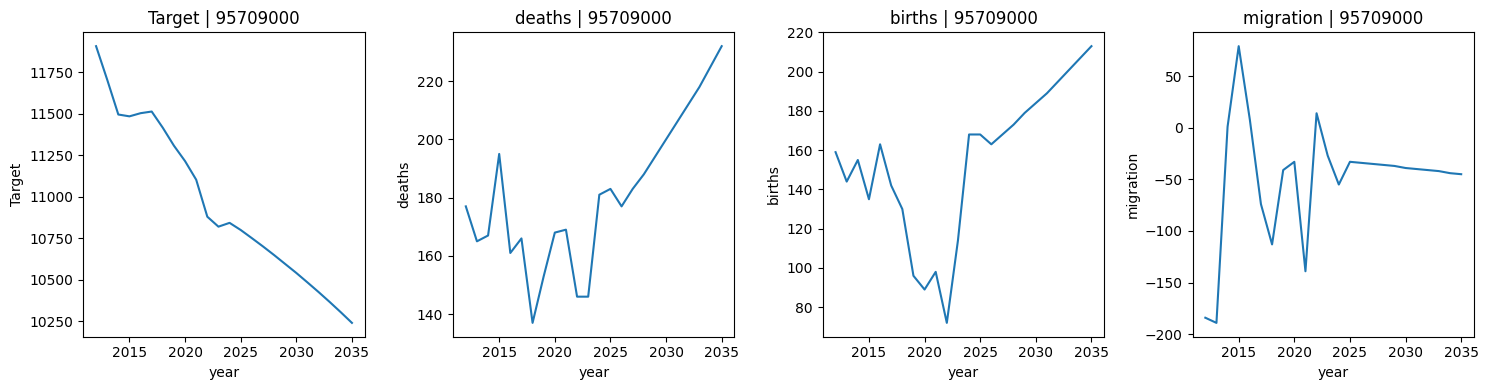

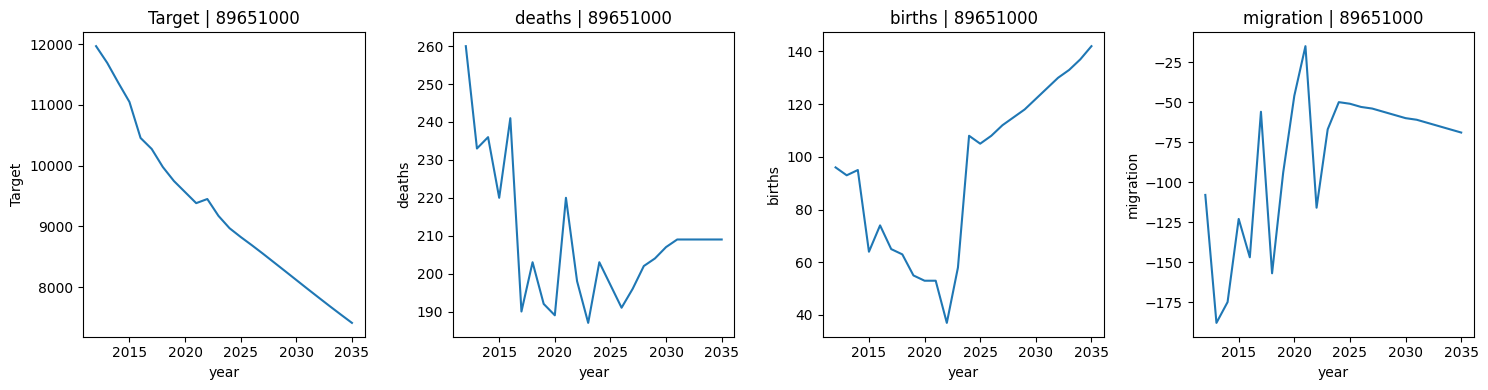

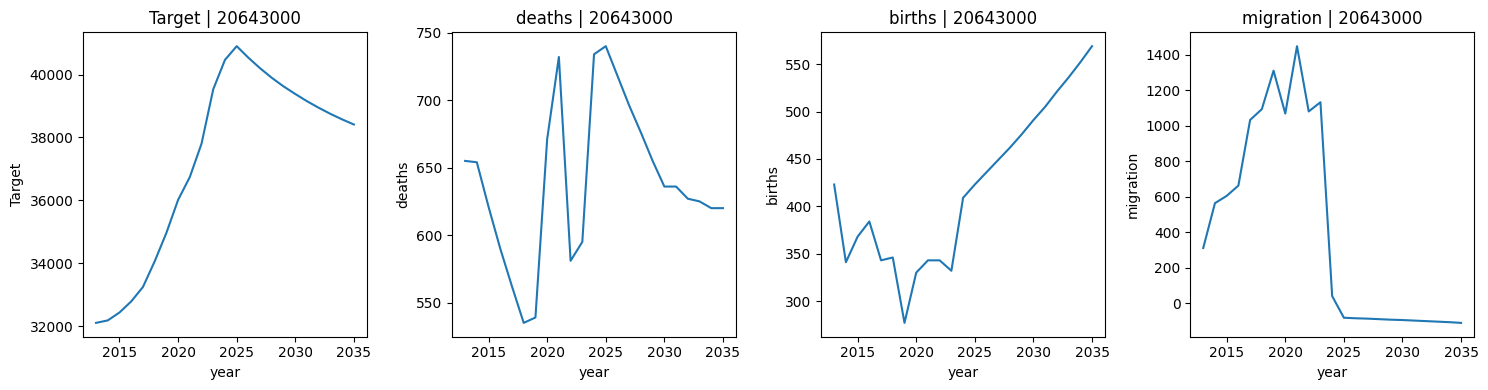

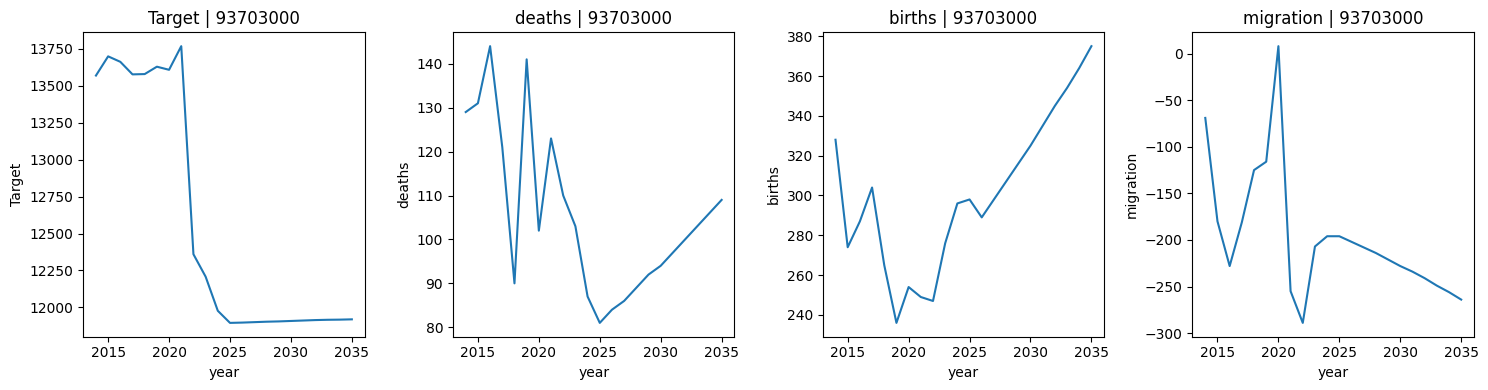

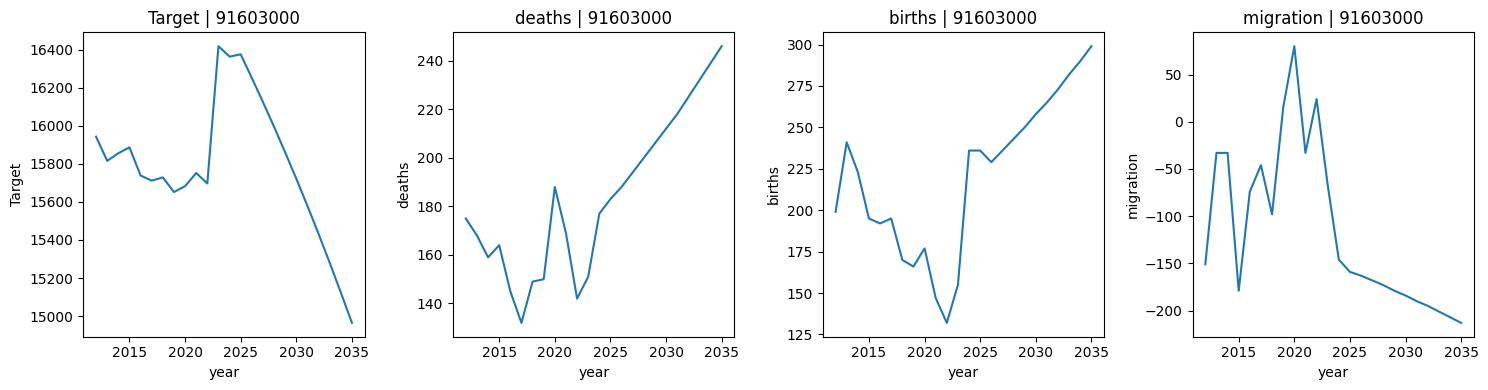

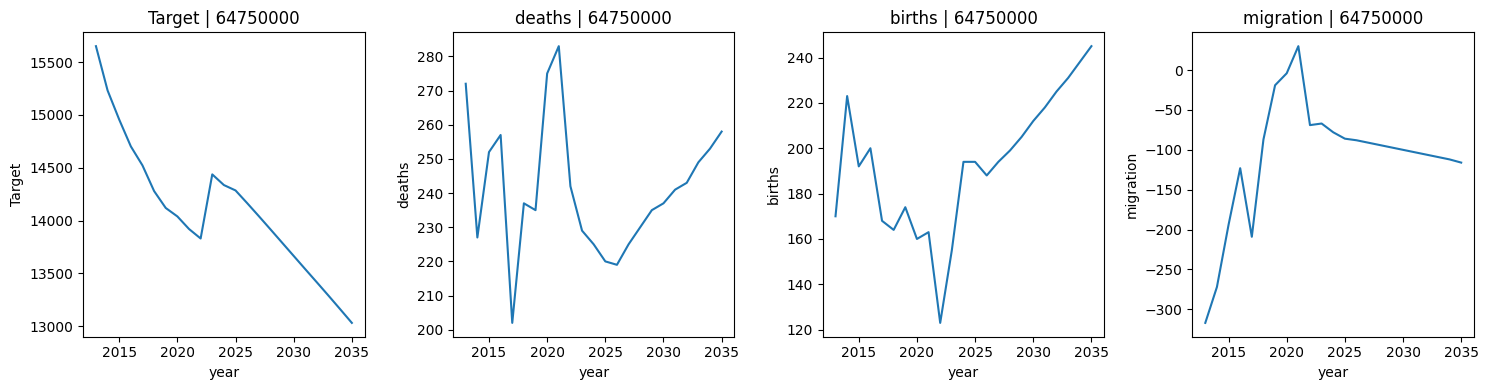

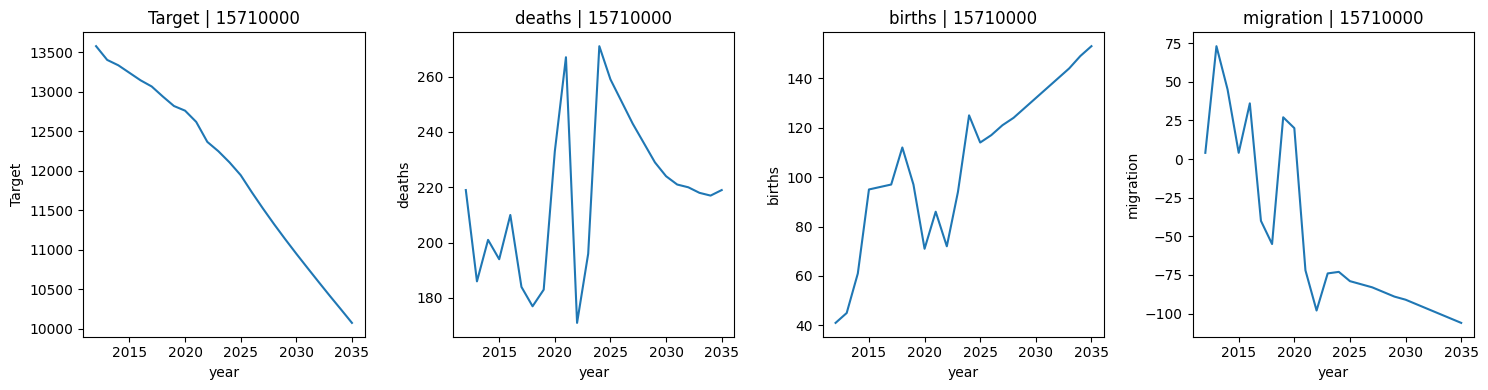

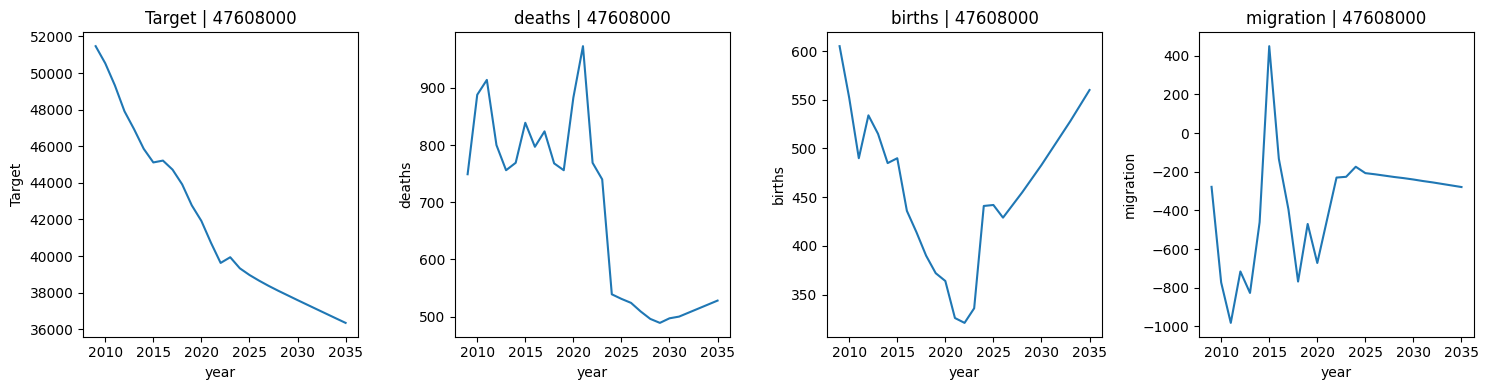

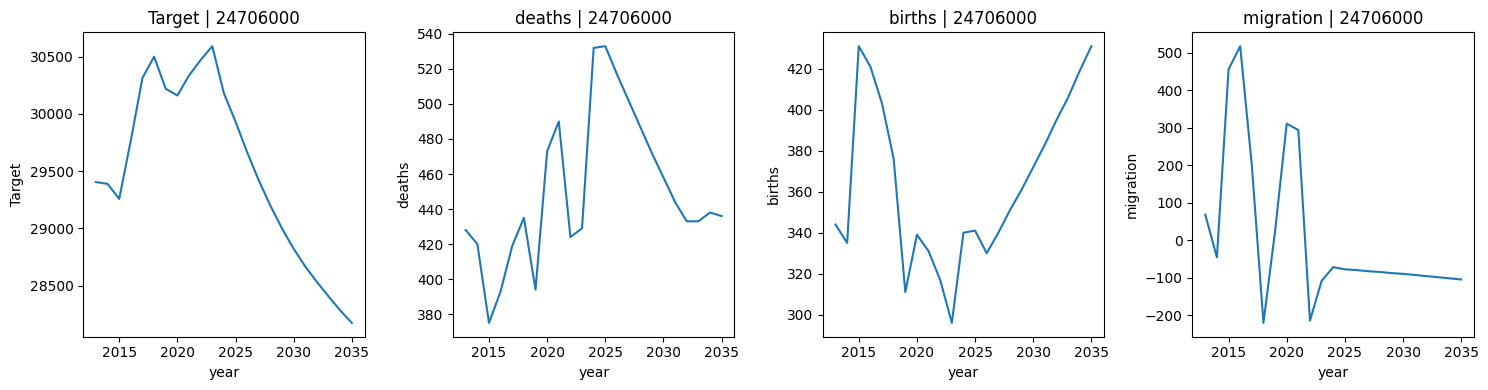

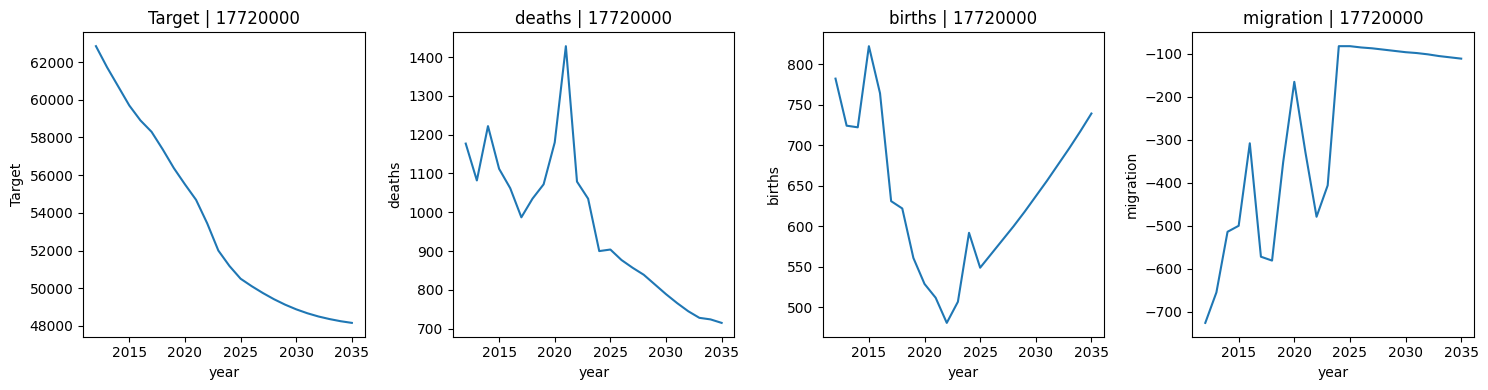

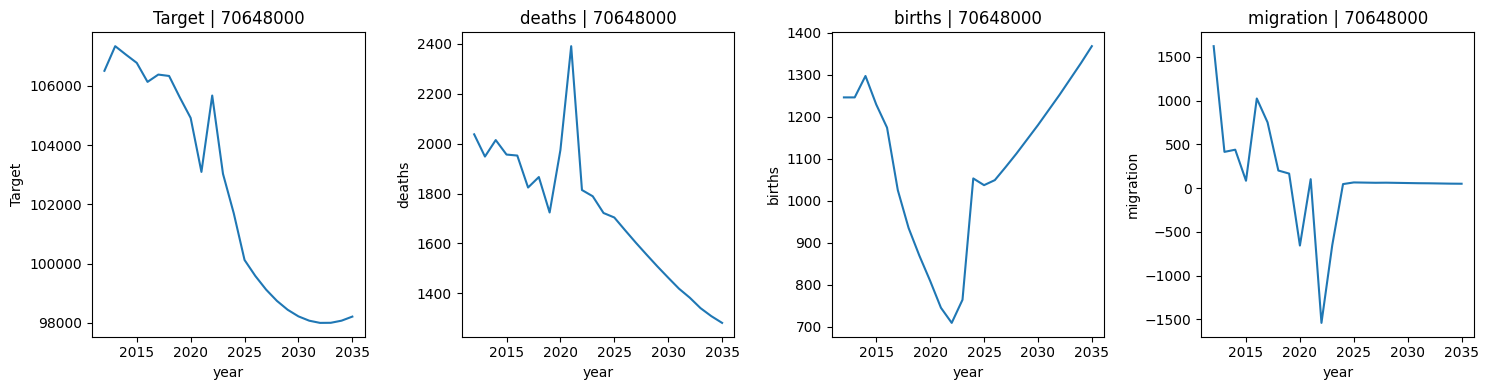

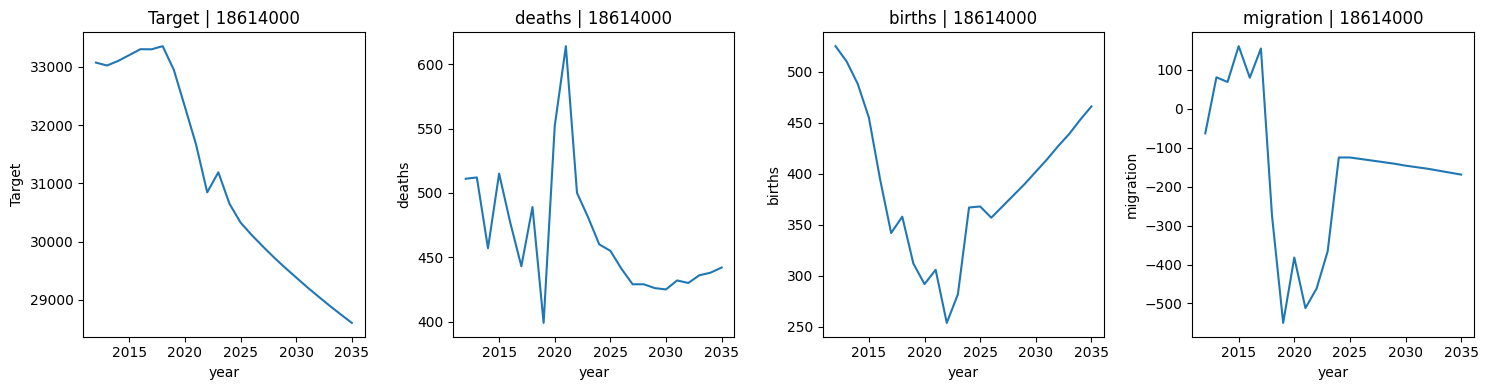

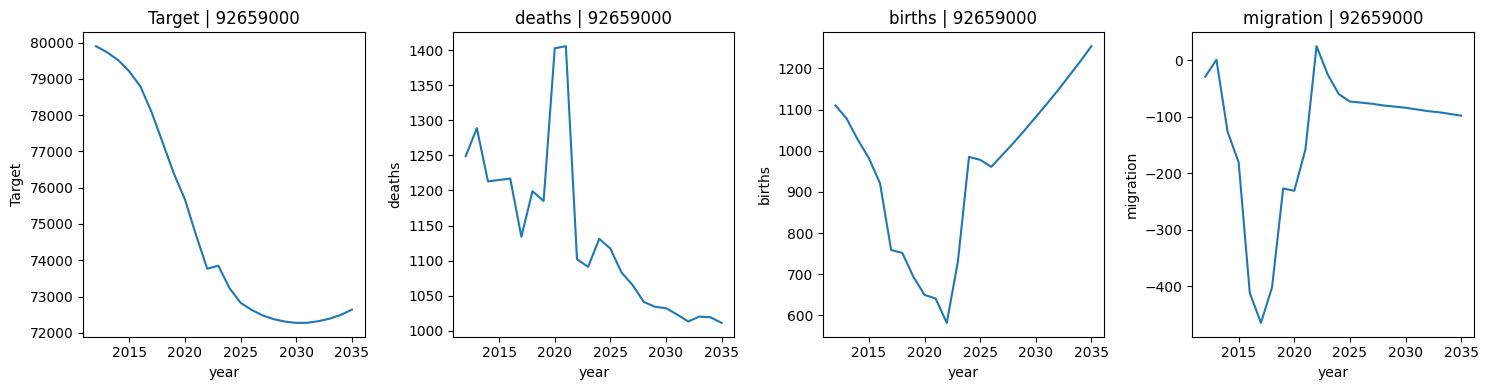

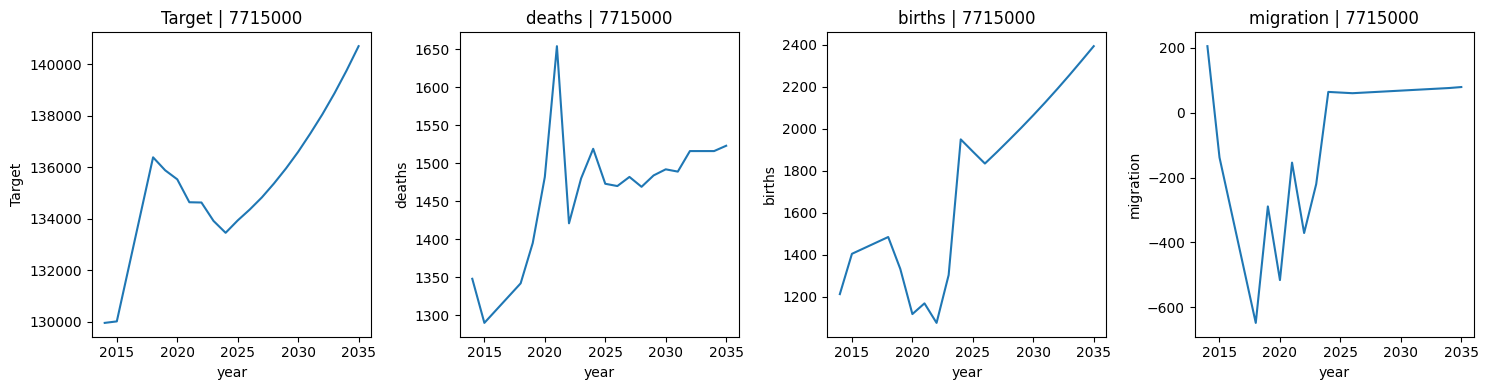

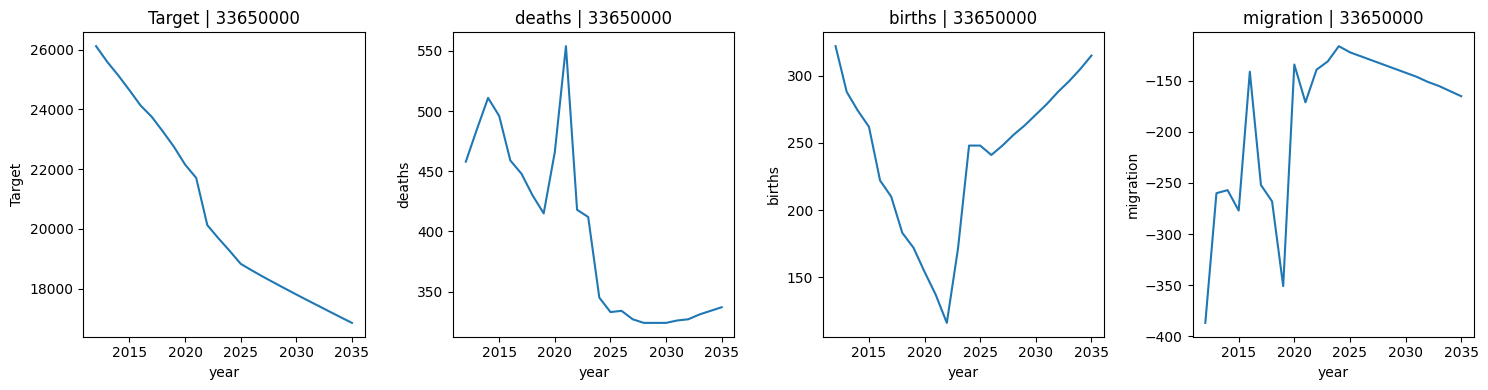

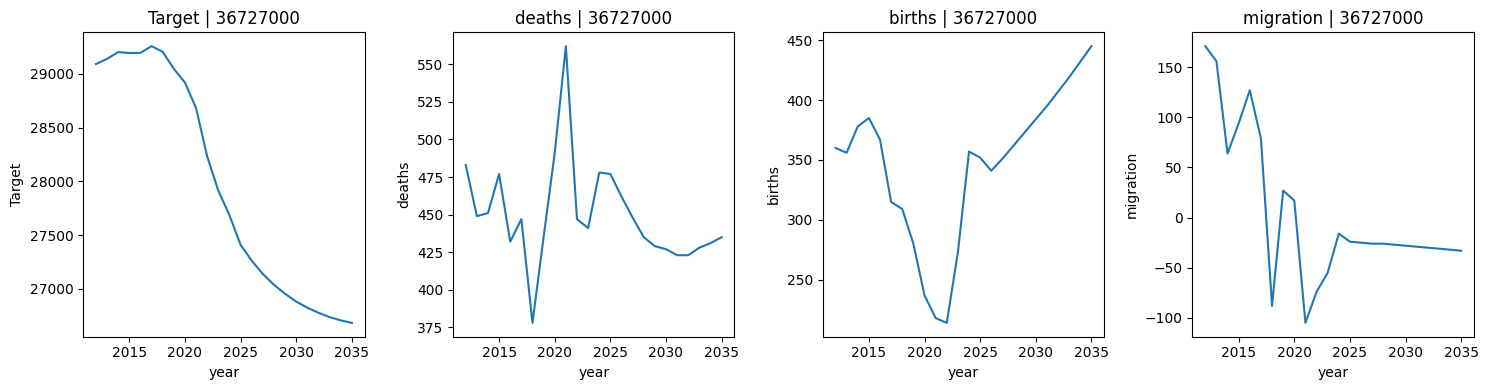

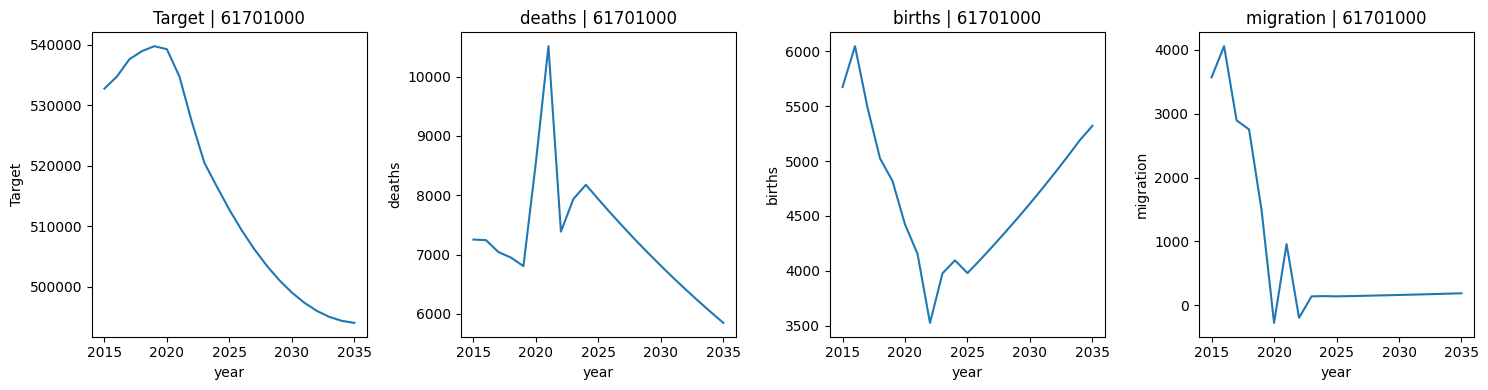

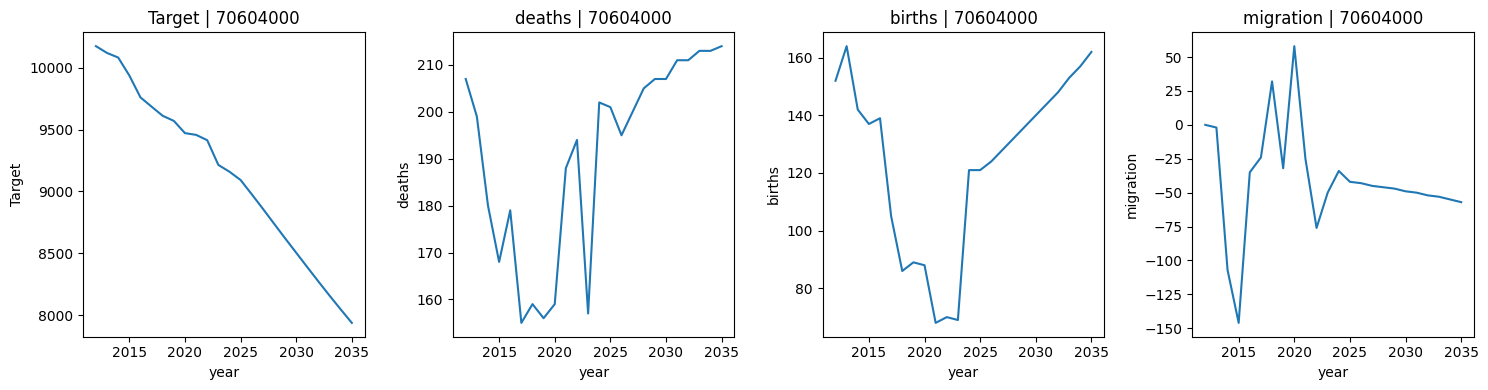

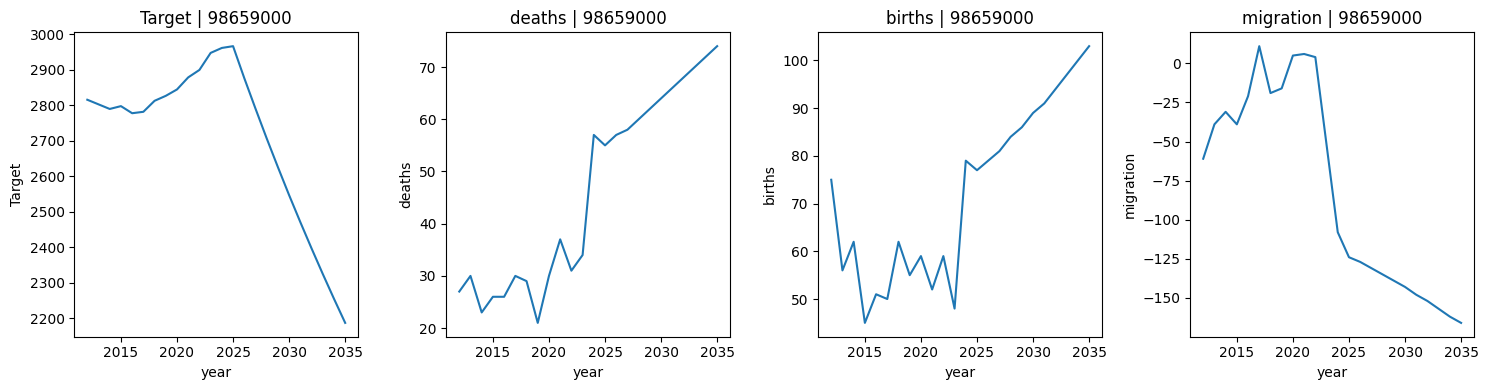

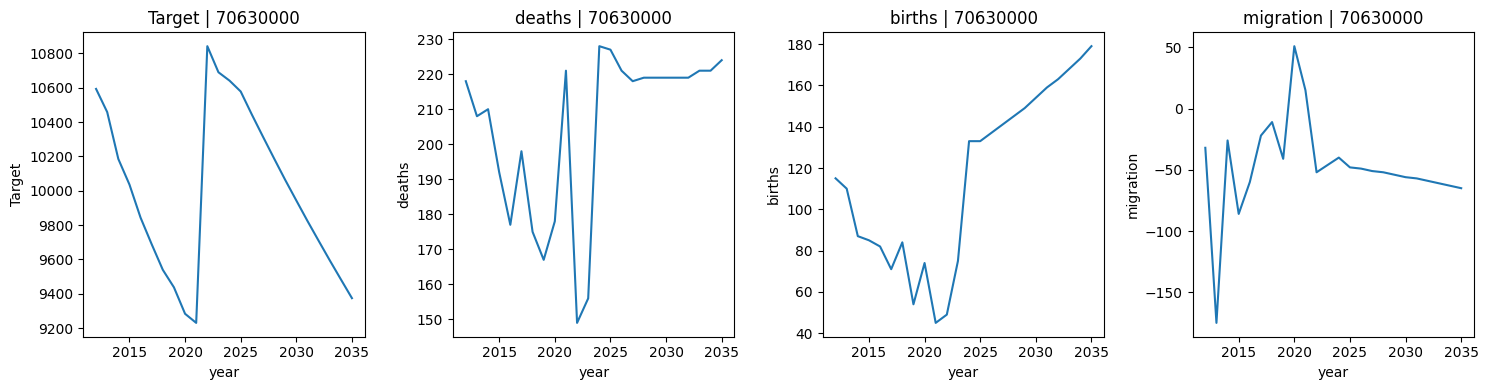

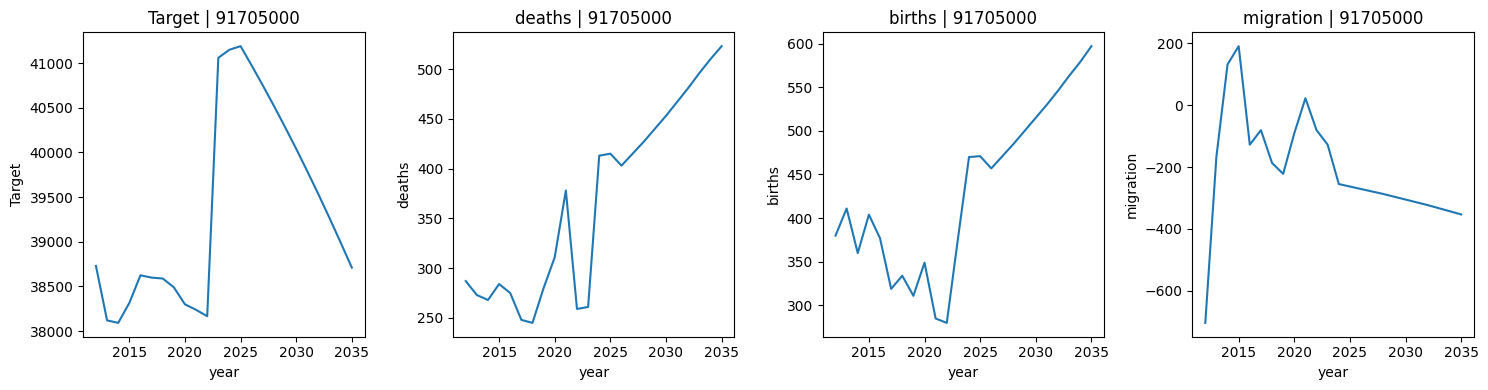

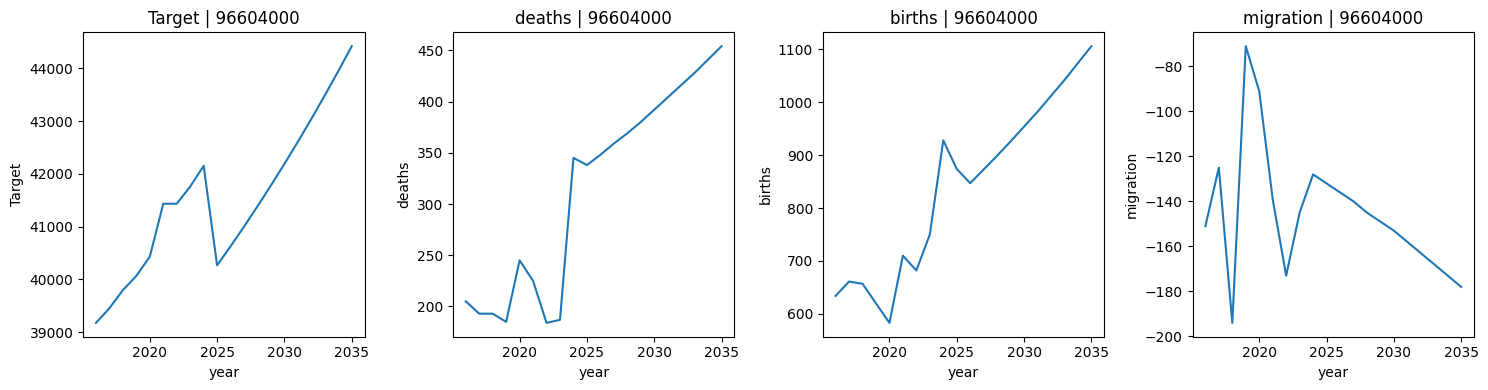

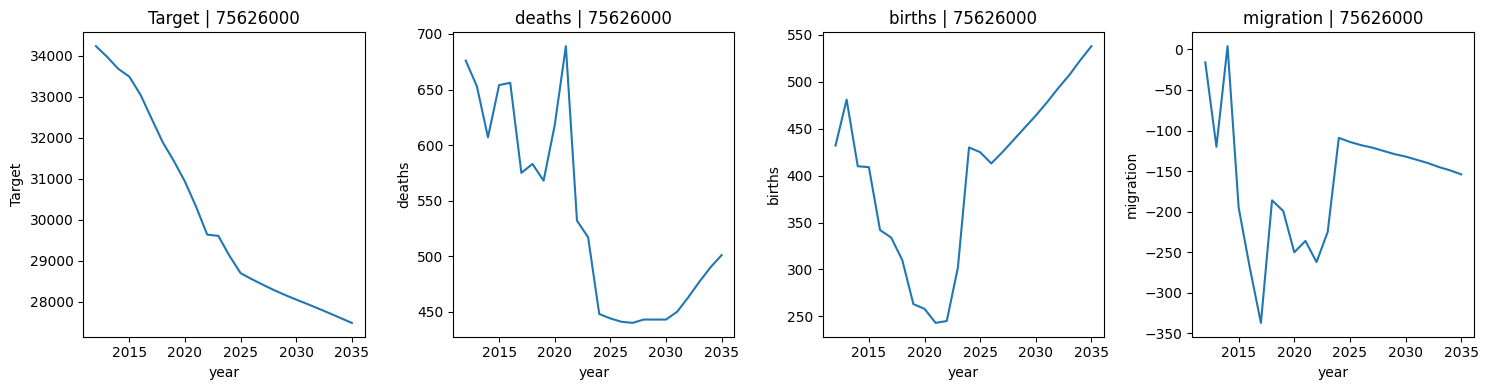

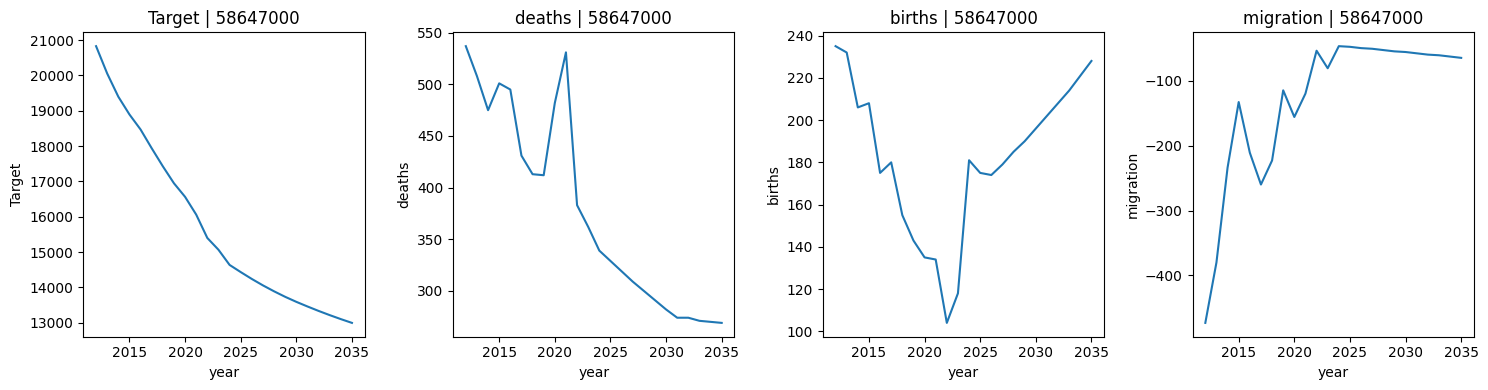

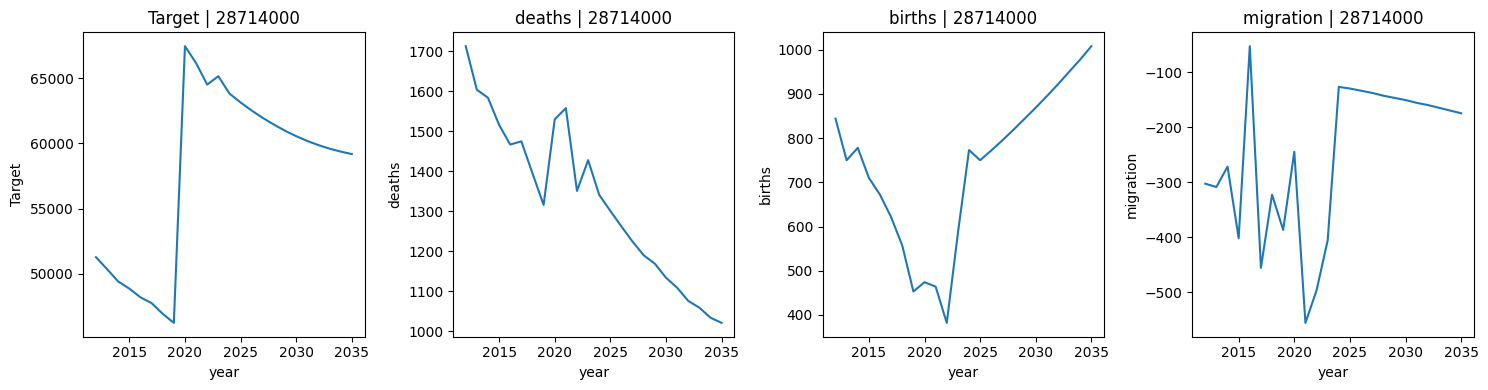

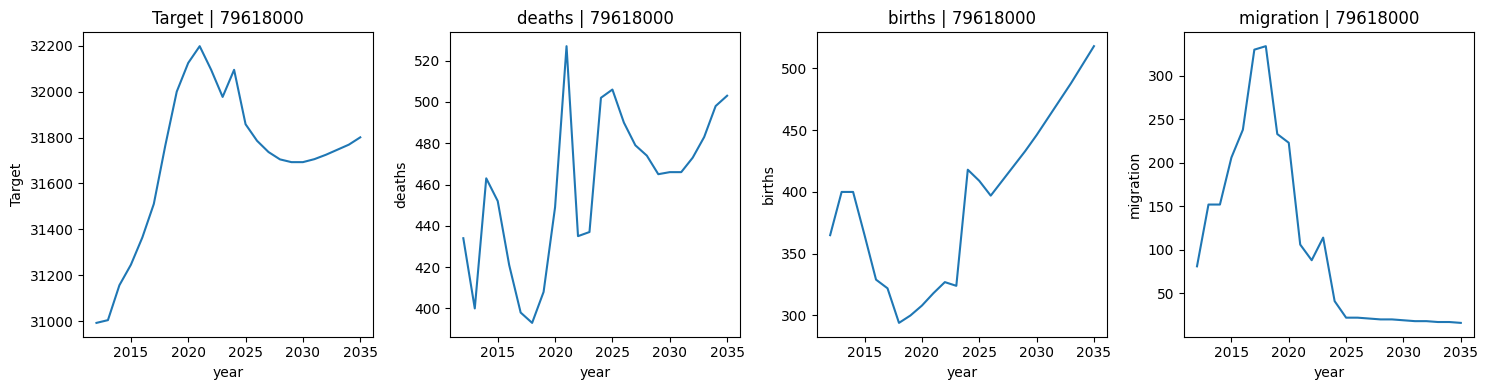

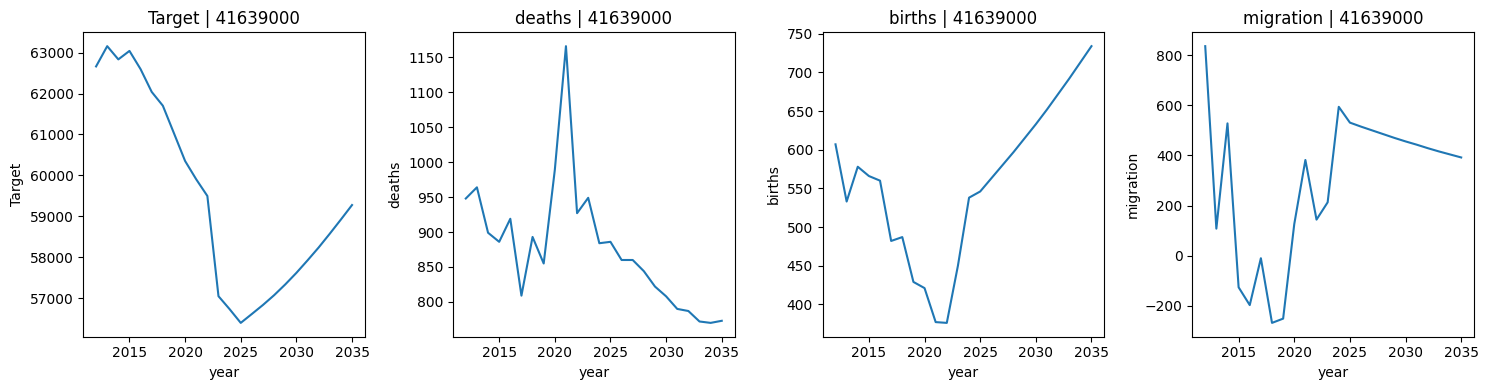

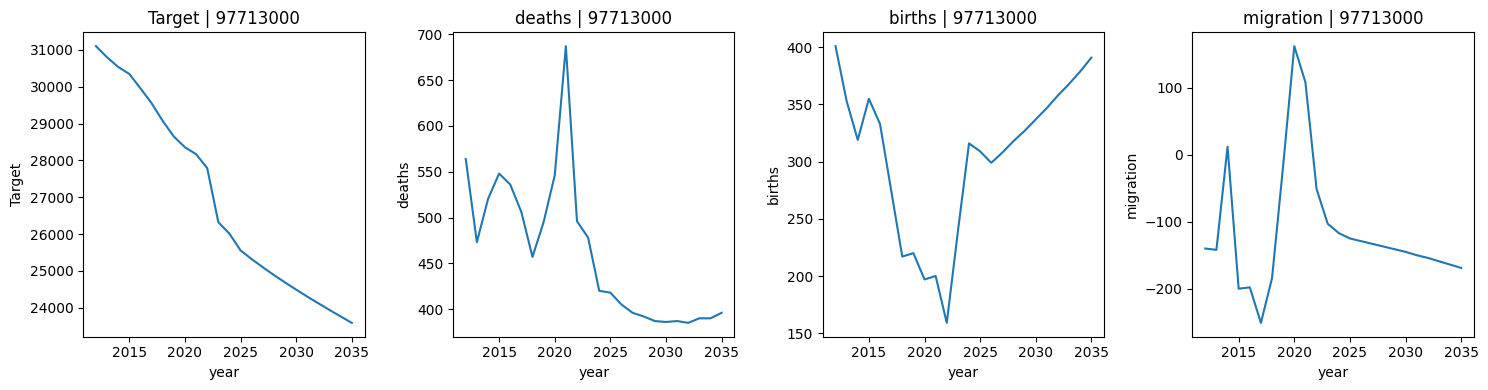

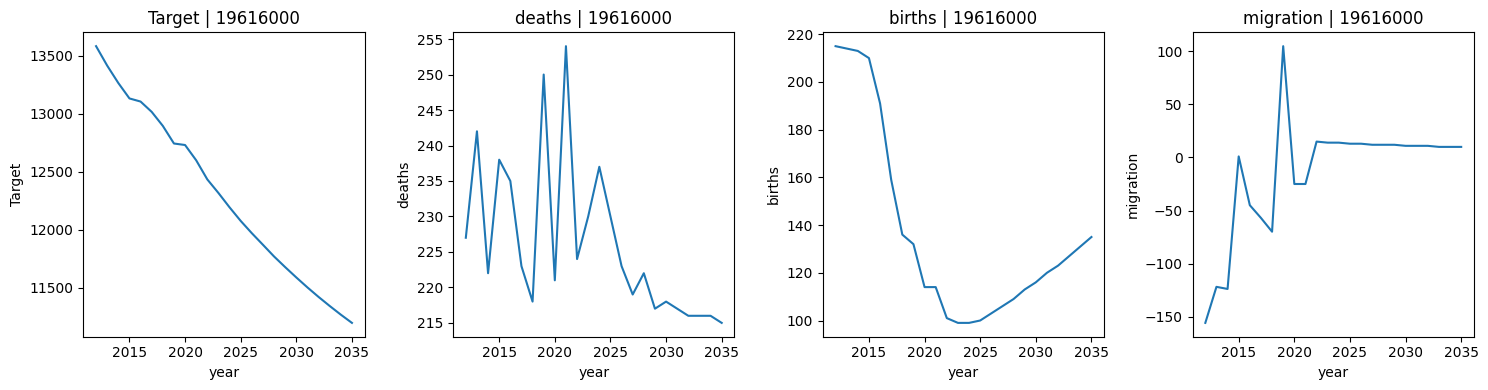

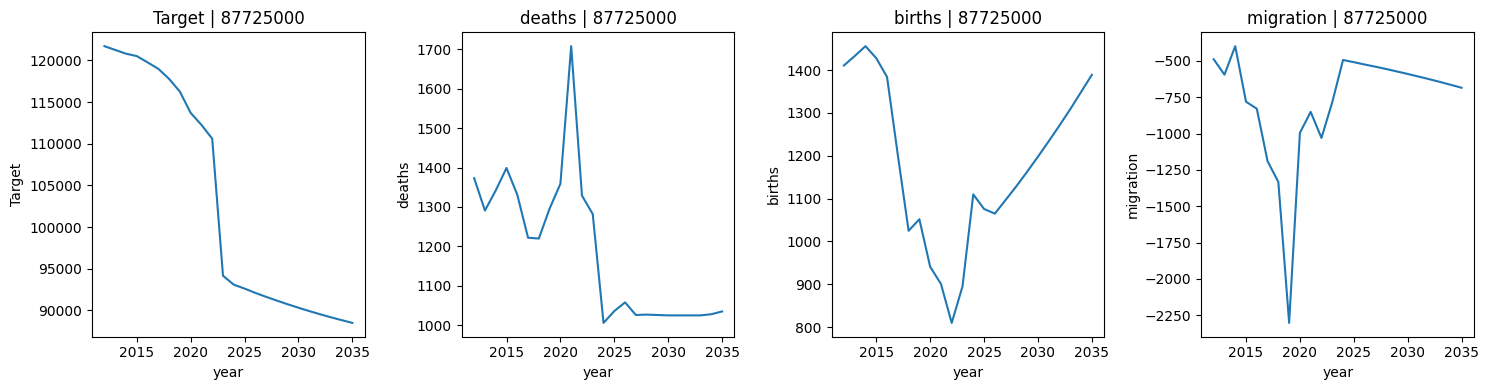

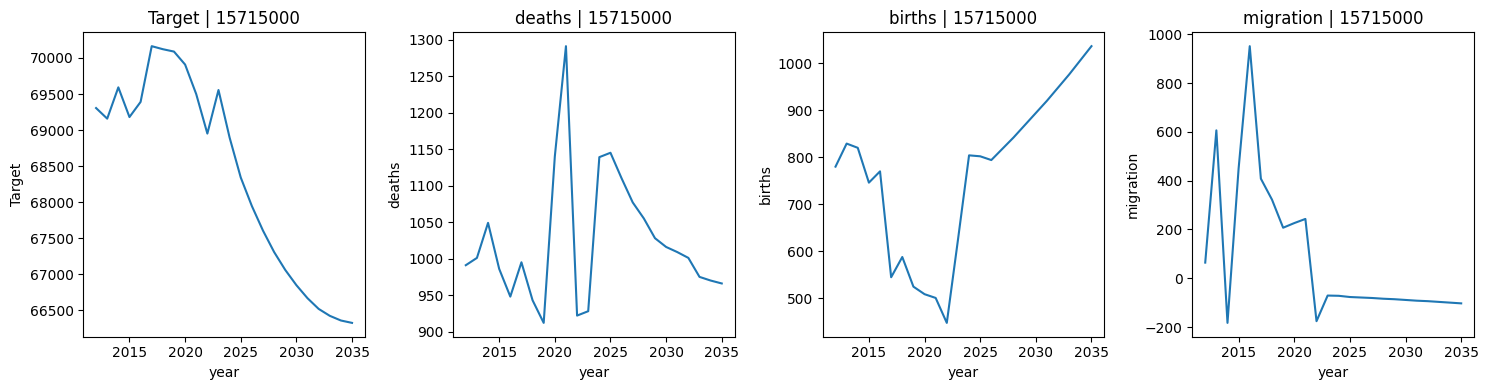

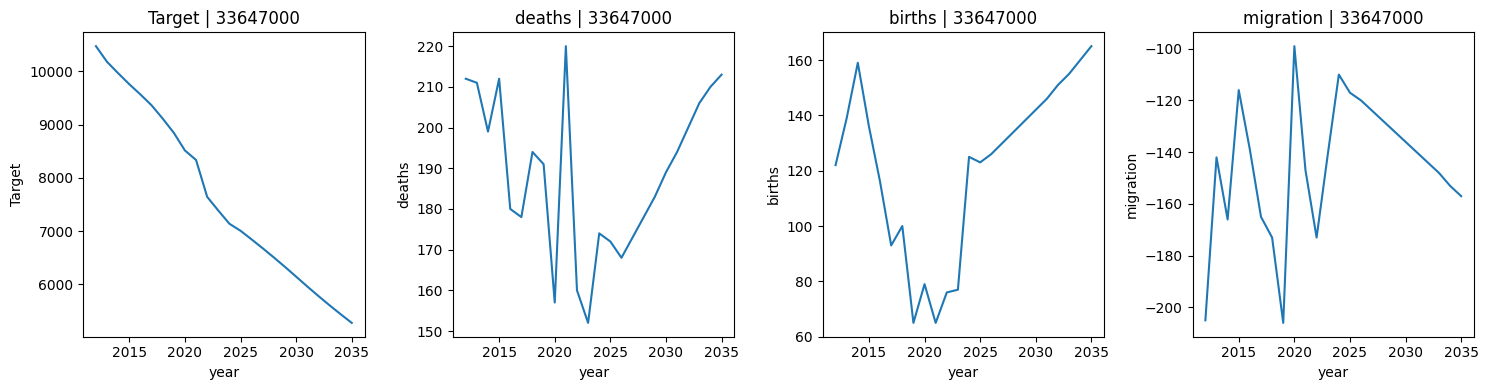

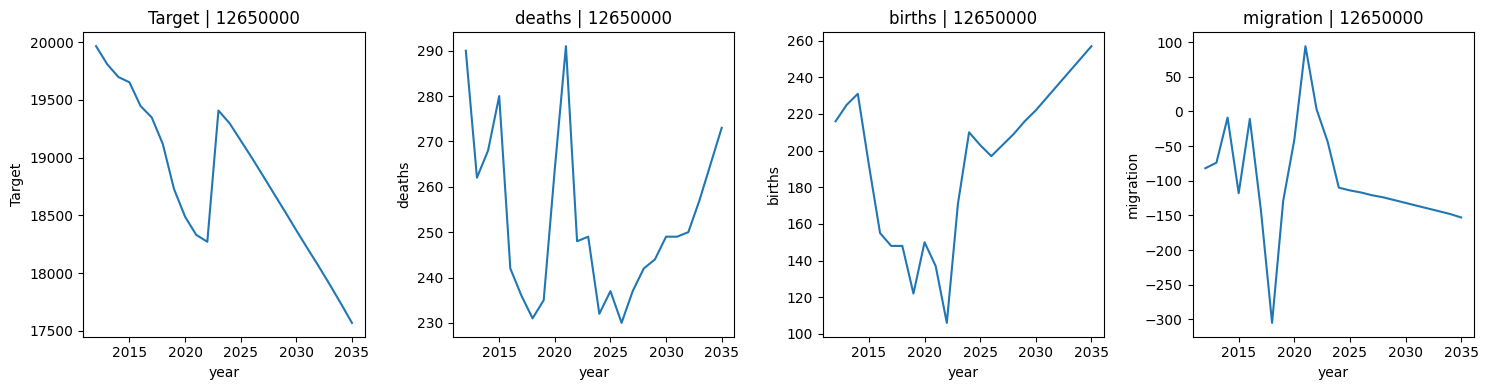

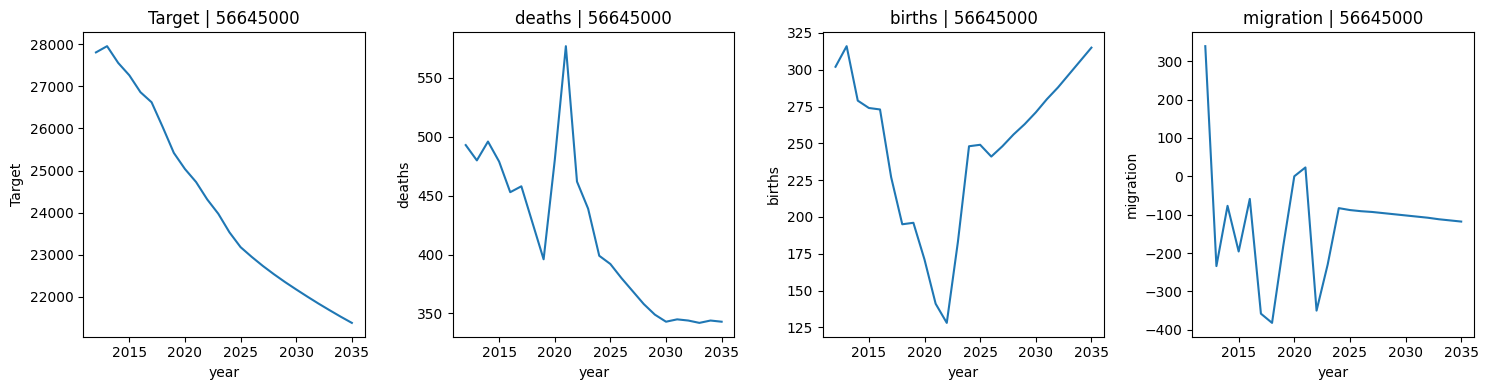

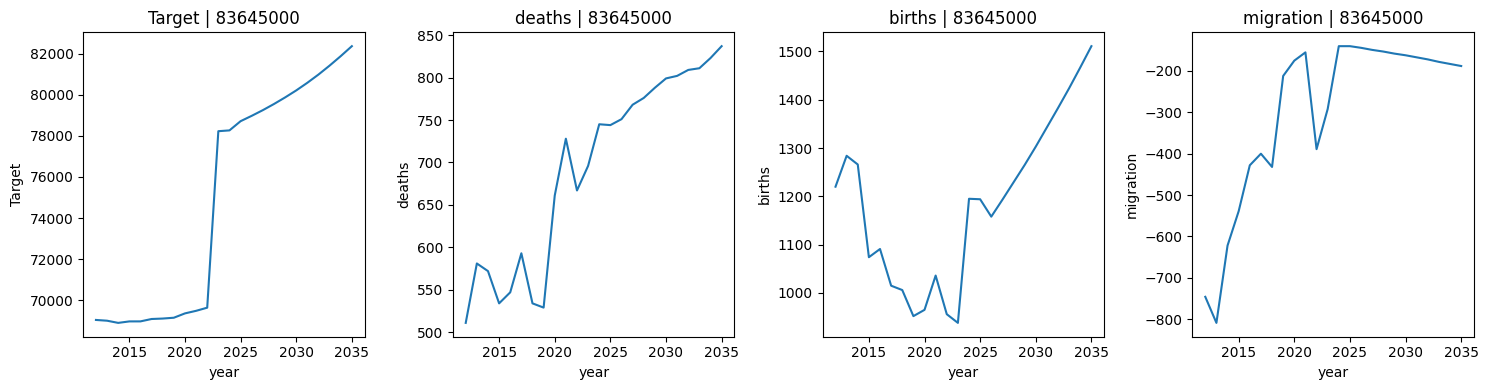

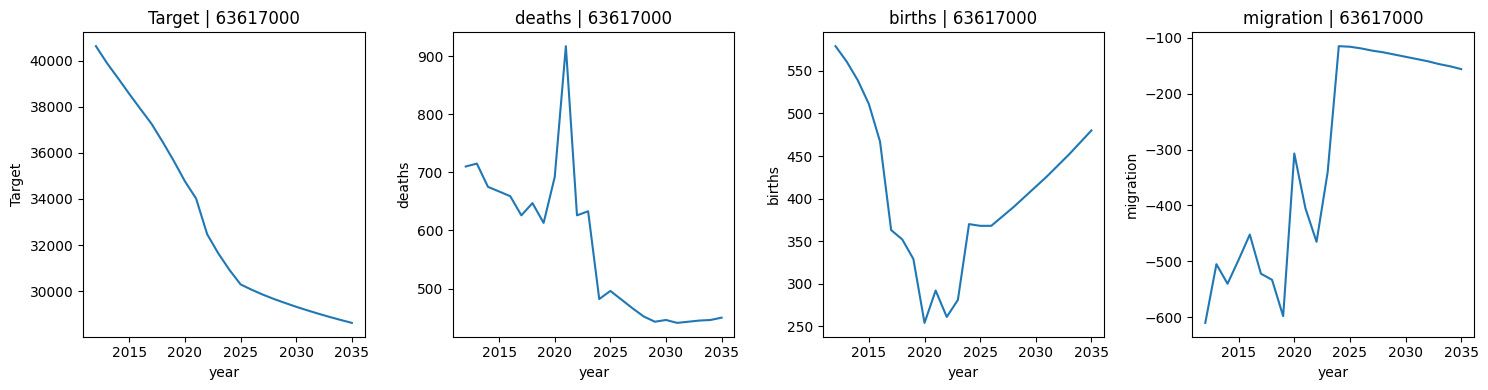

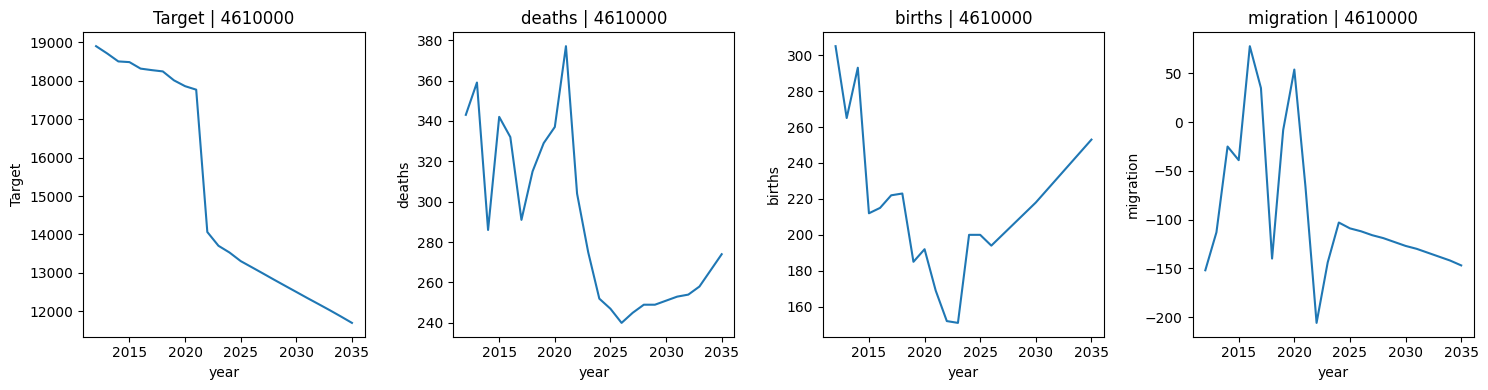

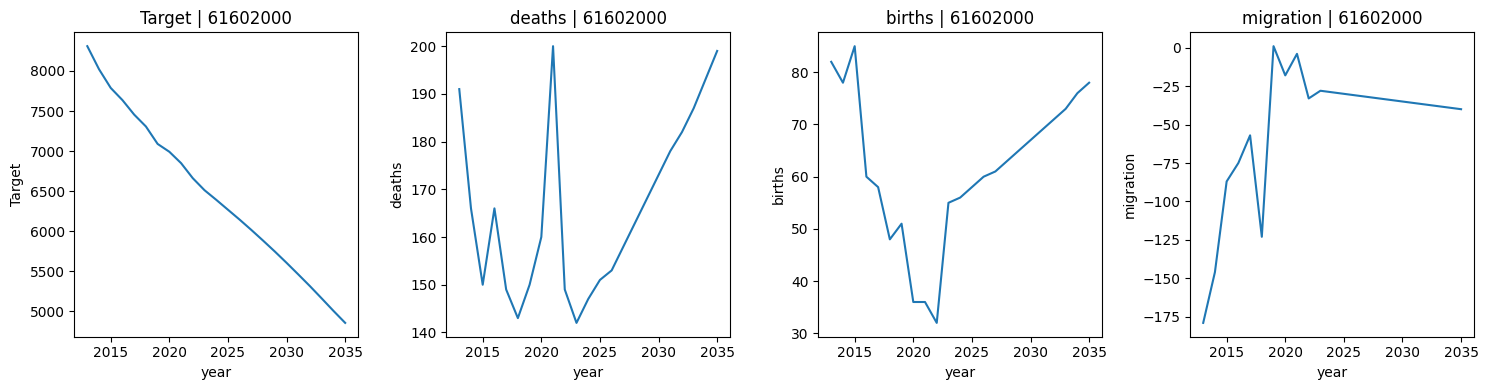

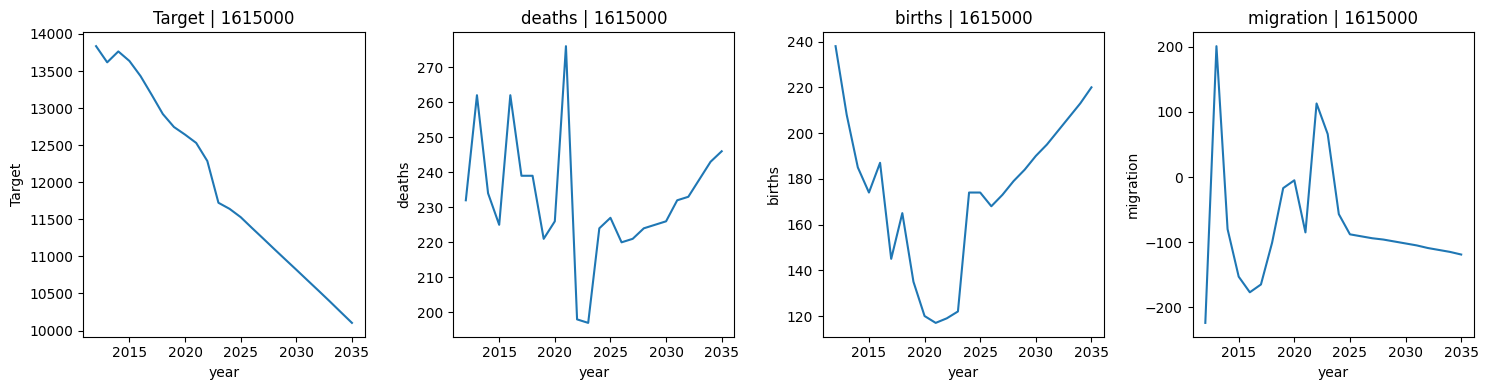

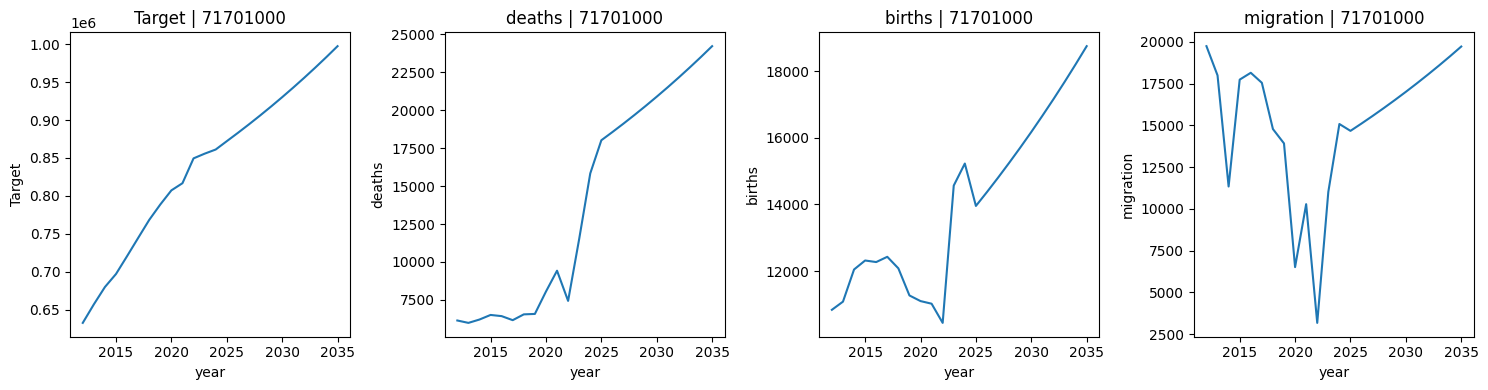

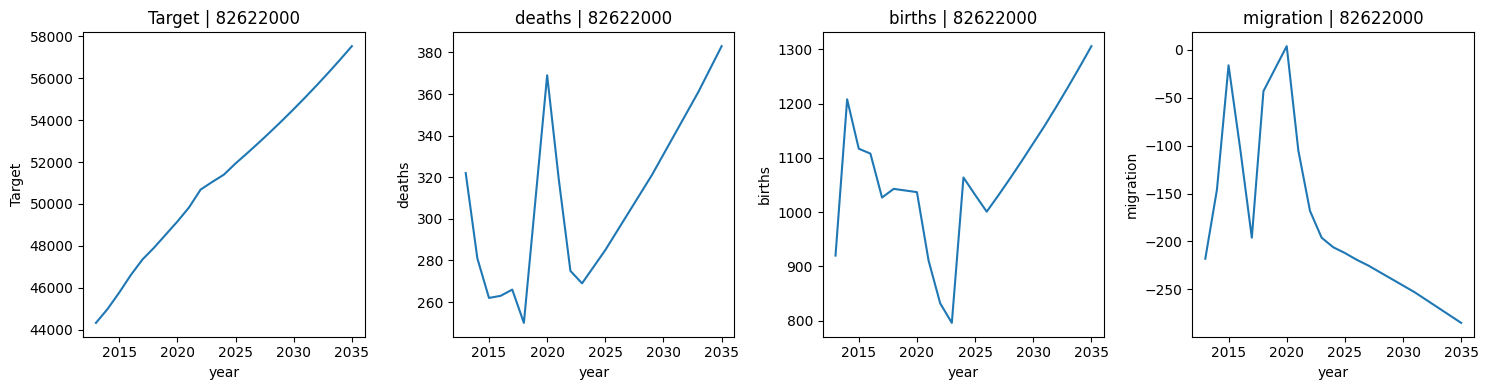

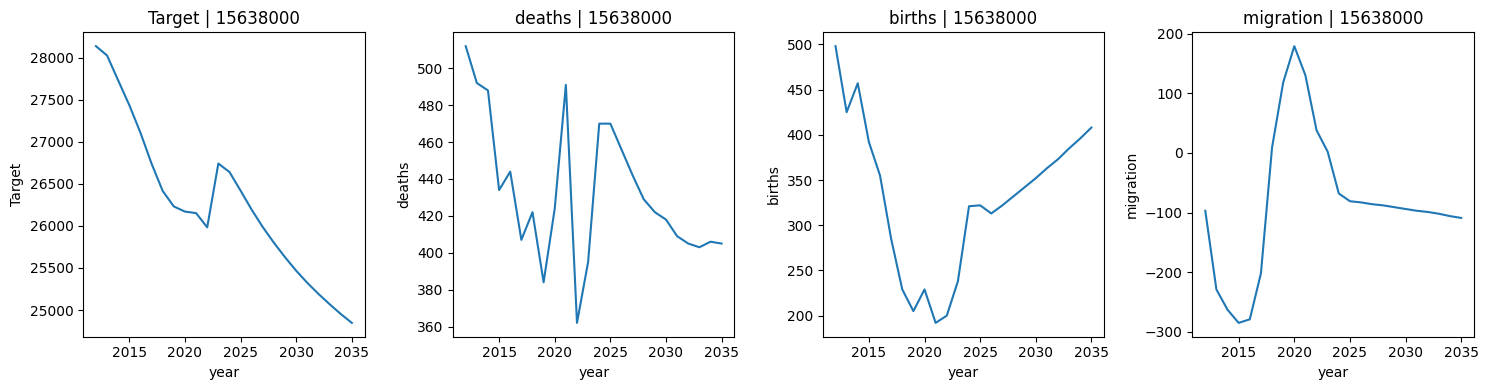

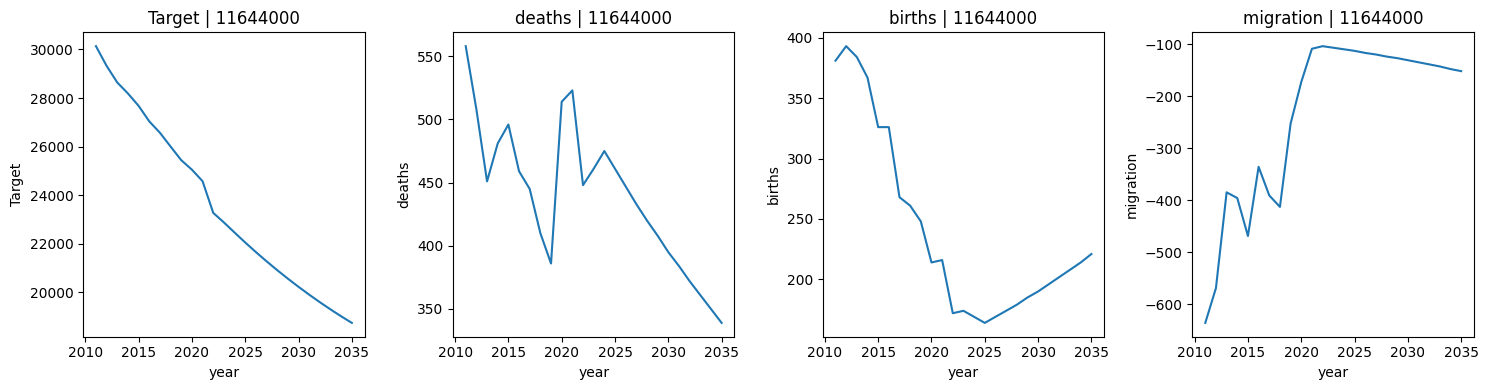

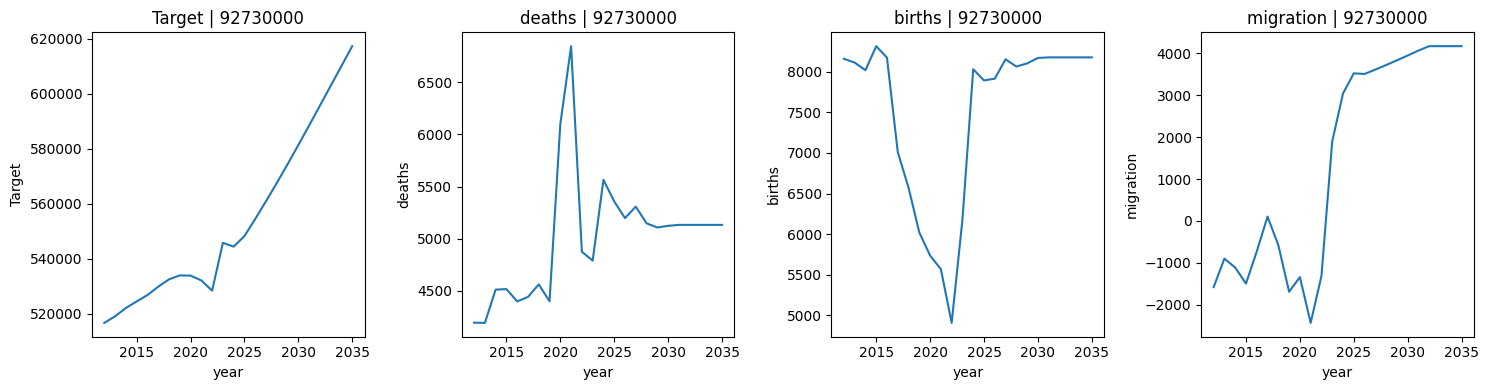

In [507]:
for i in forecast_df['oktmo'].sample(50).unique():
    fig, ax = plt.subplots(1, 4, figsize=(15 , 4))

    data = forecast_df[forecast_df['oktmo'] == i]

    for j, k in enumerate(ax):
        sns.lineplot(
            data=data,
            x='year',
            y=pred_cols[j],
            ax=k
        )
        k.set_title(f"{pred_cols[j]} | {i}")

    plt.tight_layout()
    plt.show()